In [2]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')

In [3]:
fish.columns

Index(['Species', 'Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')

In [6]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [4]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_target = fish['Species']

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(fish_input, fish_target, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((119, 5), (40, 5), (119,), (40,))

In [7]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(x_train)
x_train_scaled = ss.transform(x_train)
x_test_scaled = ss.transform(x_test)

x_train_scaled.shape, x_test_scaled.shape

((119, 5), (40, 5))

In [10]:
from sklearn.linear_model import SGDClassifier
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(x_train_scaled, y_train)
sc.score(x_train_scaled, y_train), sc.score(x_test_scaled, y_test)

c:\Users\pknukdt\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


(0.773109243697479, 0.775)

In [11]:
sc.partial_fit(x_train_scaled, y_train)
sc.score(x_train_scaled, y_train), sc.score(x_test_scaled, y_test)

(0.7983193277310925, 0.775)

In [17]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42)
train_score = []
test_score = []
classes = np.unique(y_train)

In [19]:
for _ in range(0, 300):
    sc.partial_fit(x_train_scaled, y_train, classes=classes)
    train_score.append(sc.score(x_train_scaled, y_train))
    test_score.append(sc.score(x_test_scaled, y_test))

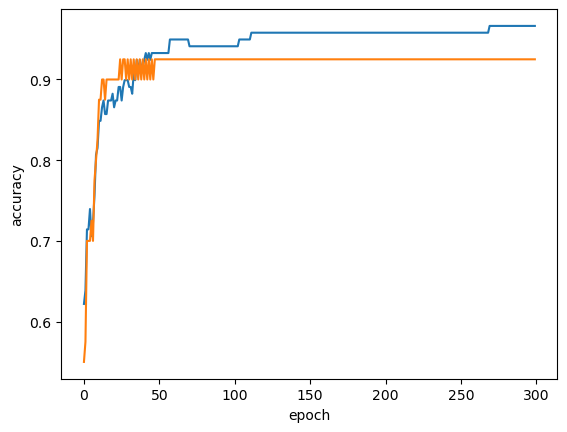

In [20]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [21]:
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(x_train_scaled, y_train)
sc.score(x_train_scaled, y_train), sc.score(x_test_scaled, y_test)

(0.957983193277311, 0.925)